# RNA velocity in the Ouroboros Sphere 


It is possible to have scVelo infer RNA velocity and to output the velocity vectors onto the sphere. 

Unfourtunately scVelo is a tricky package that doesn't always play nice with other packages, so you will need a new, specific environment for this purpose. 

Also note that scVelo requires the presence of spliced and unspliced counts in your adata.layers().

For more information on scVelo see their tutorial: [https://scvelo.readthedocs.io/en/stable/getting_started.html]

### Velocity environment 

**Dependencies**
- pandas
- anndata
- scvelo = 0.2.3
- scanpy = 1.8.2


To create run: 
```bash
conda create -n velocity_env python=3.10
conda activate velocity_env

mamba install -c conda-forge -c bioconda "scvelo>=0.2.3" "scanpy>=1.8.2" pandas anndata scikit-learn "numpy<1.24" "pynndescent>=0.5.13"
```

In [1]:
import anndata as ad
import importlib_resources as resources
import scanpy as sc
import pandas as pd
import scvelo as scv
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.transform import Rotation as R
from IPython.display import HTML



# Step 1: Read in the dataset you have run Ouroboros on
See our Scanpy/python tutorial for earlier steps. 


In [7]:
# Read in test dataset - subsetted to existing features
adata = ad.read_h5ad('output_example/example.h5ad')

We found that cell cycle velocity comes out most cleanly when using the Ouroboros feature set, rather than with all genes as is depicted in the scVelo tutorial. This is likely because dataset may have multiple trajectories (i.e. differentiaiton and cell cycle) and focusing in on only cell cycle informative genes helps to isolate the signal from just the cell cycle. 

In [8]:
#Replace with path to your installation of Ouroboros 
ouroboros_path = '/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi'
feature_set = pd.read_csv(f'{ouroboros_path}/ouroboros/data/SHAP_feature_set.csv')
feature_set = feature_set.feature_set.tolist()

# Subset to only include feature set genes 
adata_subset = adata[:, adata.var_names.isin(feature_set)].copy()

Next read in the z_df with the latent space embeddings - is the output from Ouroboros 

In [9]:
# Replace with the path to your z_df 
z_df_path = 'output_example/ouroboros_embeddings_pseudotimes.csv'

z_df = pd.read_csv(z_df_path)
z_df = z_df.set_index('Unnamed: 0')
z_df

,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,dormancy_depth
Unnamed: 0,,,,,,
CTGATCCGTCAGACTT_SRX17782706,0.997972,-0.060443,-0.019959,S,0.777424,NaN
GCCCGAAAGTAGTGCG_SRX17782704,0.062366,-0.522792,0.850176,G1,0.030358,NaN
CCGATGGTCTGATGGT_SRX17782709,0.298726,-0.716041,0.630910,G2M,0.973088,NaN
CCTCTCCGTTATGTCG_SRX17782704,-0.785088,0.544524,-0.295178,G0,NaN,-0.232186
AGCGTATGTCTACACA_SRX17782704,-0.179392,0.719529,-0.670892,G1-G0 transition,NaN,-0.194541
...,...,...,...,...,...,...
TTGTGTTAGCGACAGT_SRX17782709,-0.941296,0.337502,0.007401,G0,NaN,-0.241869
ACTGTCCAGTCCTACA_SRX17782709,-0.341617,0.156724,0.926680,G1,0.160973,NaN
TCGCTCAAGCACTCAT_SRX17782706,-0.567939,0.764667,-0.304516,G0,0.405928,-0.161059


If you plan on using a robinson projection to display your data in 2D, I highly recommend rotating the sphere so the cycle pole is the true north-south axis - it will look much more comprehensible in 2D. 

We can't access Ouroboros functions here because scVelo conflicts with some of the Ouroboros dependencies, so I have included the base code for the find_cycle_pole() and rotate_north() function here for you to run. 

### Extra steps if you retrained the VAE because you had missing genes

If you retrained the VAE because of missing genes, your cell cycle pole will have changed  - find the new one like so:

The plots will work without doing this step, but your axis will look funky 

In [ ]:
# Functions necessary 
def fit_great_circle(points):
    """ Fit a great circle around the sphere capturing variation along a set of points
    points = set of points"""
    # Perform PCA to find the plane
    pca = PCA(n_components=3)
    pca.fit(points)
    normal_vector = pca.components_[2]  # Normal vector to the plane
    plane_vectors = pca.components_[:2]  # Basis vectors for the plane

    # Generate great circle points
    t = np.linspace(0, 2 * np.pi, 100)
    circle_points = (
        np.outer(np.cos(t), plane_vectors[0]) +
        np.outer(np.sin(t), plane_vectors[1])
    )
    return circle_points,normal_vector



def find_cycle_pole(z_df, ref_embed, phase_category = 'KNN_phase'):
    """ Find a point on the sphere's surface that represents the centre of the cycling cells
    z_df: embedded points including cycling cells to find the centre of
    ref_embed: reference embedded points 
    phase_category: name of the columns with phase labels to parse (needs to have G1/S/G2M)"""
    cyc = z_df[z_df[phase_category].isin(['G2M', 'S', 'G1'])]
    points = cyc[['dim1', 'dim2', 'dim3']].values
    # Fit the great circle
    great_circle, normal_vector = fit_great_circle(points)
    top_center = normal_vector / np.linalg.norm(normal_vector)

    # Little test to make sure top point is in the middle of cycling cells and not G0 cells
    cyc = ref_embed[ref_embed['KNN_phase'].isin(['G2M', 'S', 'G1'])]
    points = cyc[['dim1', 'dim2', 'dim3']].values

    ## Get centroid of G1, S, G2M cells
    cyc_centroid = np.mean(points, axis=0)
    ## Get centroid of G0 cells
    g0 = ref_embed[ref_embed['KNN_phase'] == 'G0']
    g0_points = g0[['dim1', 'dim2', 'dim3']].values
    g0_centroid = np.mean(g0_points, axis=0)
    ## Compute dot products
    dot_cyc = np.dot(top_center, cyc_centroid)
    dot_g0 = np.dot(top_center, g0_centroid)
    ## If top_center aligns more with G0, flip it
    if dot_g0 > dot_cyc:
        top_center = -top_center
    return top_center


def rotate_north(z_df, reference_CC_pole_point = [0.86202236, 0.24824865, 0.44191636]):
    """Rotate the cell cycle pole to be north pole
    Note: will replace dim1, dim2, dim3 in z_df"""
    new_df = z_df.copy()
    # Reference point
    reference_CC_pole_point = np.array(reference_CC_pole_point)
    target_vector = reference_CC_pole_point / np.linalg.norm(reference_CC_pole_point)
    # Default North Pole
    north_pole = np.array([0, 0, 1])

    # Compute rotation axis and angle
    rotation_axis = np.cross(target_vector, north_pole)
    if np.linalg.norm(rotation_axis) > 1e-8:  # Avoid division by zero for near-parallel vectors
        rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)
    rotation_angle = np.arccos(np.clip(np.dot(target_vector, north_pole), -1.0, 1.0))

    # Create the rotation
    rotation = R.from_rotvec(rotation_axis * rotation_angle)

    # Extract coordinates
    coordinates = new_df[['dim1', 'dim2', 'dim3']].values

    # Apply the rotation
    rotated_coordinates = rotation.apply(coordinates)

    # Update z_df with the rotated coordinates
    new_df[['dim1', 'dim2', 'dim3']] = rotated_coordinates
    return new_df

In [ ]:
# Find the pole of the retrained sphere - NOT NECESSARY IF NO RETRAINING
ref_embed = pd.read_csv('output_example/ouroboros_embeddings_pseudotimes.csv')
cycle_pole = find_cycle_pole(z_df, ref_embed)

# To rotate your points and set the cycle pole as the north-south axis, define and run the rotate_north() function 
rotated_z_df = rotate_north(z_df, cycle_pole = cycle_pole)

# Write rotated z_df to a csv so we can use it for 2D robinson projection plotting later
rotated_z_df.to_csv('output_example/north_rotated_example_embeddings.csv')

ScVelo typically works on the dimensions of a UMAP embedding in adata.obsm. To make it accept the latent space instead, we just have to trick it by setting adata.obsm['X_umap'] to be our latent space instead of a UMAP embedding, and then scVelo can run as it normally would. 

In [ ]:
latent_space = z_df[['dim1', 'dim2', 'dim3']].values # if you rotated the sphere use rotated_z_df[['dim1', 'dim2', 'dim3']].values

# Set X_umap to be our latent space instead of a UMAP 

adata.obsm['X_umap'] = latent_space

Normalized count data: X, spliced, unspliced.
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/144 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


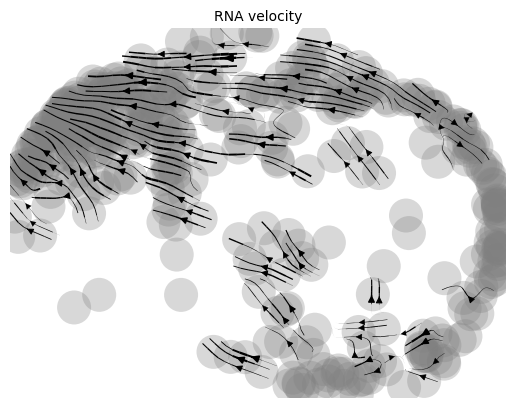

In [11]:
# Then scVelo can be run as it normally would be on the adata
## For more info on scVelo see their tutorial: [https://scvelo.readthedocs.io/en/stable/getting_started.html]
vel = adata.copy()
scv.pp.moments(vel, n_neighbors = 20, use_highly_variable = False)
scv.tl.velocity(vel, mode='stochastic')
scv.tl.velocity_graph(vel)
scv.pl.velocity_embedding_stream(vel, basis='umap', title = 'RNA velocity')

We can then take the velocity vectors straight from the adata itself: 

In [12]:
vel_df = pd.DataFrame(vel.obsm['velocity_umap'], columns = ['dim1', 'dim2', 'dim3'], index = vel.obs.index)

vel_df.to_csv('output_example/example_velocity_df.csv')

We can't access Ouroboros functions like plot_sphere() here because scVelo conflicts with some of the Ouroboros dependencies. 

So, to plot these vectors onto the sphere, you can save the velocity dataframe to a csv, and load them into a new notebook using the ouroboros_env kernal. 

Here we switch to our ouroboros_env to run this code: 

In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
import ouroboros as obo
import importlib_resources as resources
import seaborn as sns
import pandas as pd
import cartopy.crs as ccrs

# this is just for the tutorial rendering
from IPython.display import IFrame


In [12]:
# Read in your latent space embeddings - if you rotated before calling velocity make sure you read in the rotated coordinates 
# Replace with the path to your z_df 
z_df_path = 'output_example/ouroboros_embeddings_pseudotimes.csv' 
# if rotated sphere you would use those coords instead: 
z_df_path = 'output_example/north_rotated_example_embeddings.csv' 



z_df = pd.read_csv(z_df_path)
z_df = z_df.set_index('Unnamed: 0')
z_df

,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,dormancy_depth
Unnamed: 0,,,,,,
CTGATCCGTCAGACTT_SRX17782706,0.509849,-0.201015,0.836449,S,0.777424,NaN
GCCCGAAAGTAGTGCG_SRX17782704,-0.625056,-0.720759,0.299685,G1,0.030358,NaN
CCGATGGTCTGATGGT_SRX17782709,-0.292811,-0.886395,0.358562,G2M,0.973088,NaN
CCTCTCCGTTATGTCG_SRX17782704,-0.206861,0.711044,-0.672030,G0,NaN,-0.232186
AGCGTATGTCTACACA_SRX17782704,0.384595,0.881948,-0.272496,G1-G0 transition,NaN,-0.194541
...,...,...,...,...,...,...
TTGTGTTAGCGACAGT_SRX17782709,-0.512673,0.460938,-0.724363,G0,NaN,-0.241869
ACTGTCCAGTCCTACA_SRX17782709,-0.987645,-0.029321,0.153940,G1,0.160973,NaN
TCGCTCAAGCACTCAT_SRX17782706,-0.126240,0.891869,-0.434319,G0,0.405928,-0.161059


In [3]:
# Read in your velocity vectors for those embeddings 
vel_df = pd.read_csv('/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi/docs/output_example/example_velocity_df.csv')
vel_df = vel_df.set_index('Unnamed: 0')
vel_df

,dim1,dim2,dim3
Unnamed: 0,,,
CTGATCCGTCAGACTT_SRX17782706,0.000504,-0.017823,0.016450
GCCCGAAAGTAGTGCG_SRX17782704,-0.029637,0.012006,-0.017993
CCGATGGTCTGATGGT_SRX17782709,-0.012599,0.001497,0.000276
CCTCTCCGTTATGTCG_SRX17782704,-0.011829,0.000158,0.012084
AGCGTATGTCTACACA_SRX17782704,-0.040555,0.007306,0.009799
...,...,...,...
TTGTGTTAGCGACAGT_SRX17782709,-0.007747,0.019716,-0.006064
ACTGTCCAGTCCTACA_SRX17782709,-0.014259,0.009563,0.002049
TCGCTCAAGCACTCAT_SRX17782706,-0.019673,-0.008066,-0.032348


In [8]:

# Plot the sphere as before, but give the velocity vector df to the parameter velocity to have it plot the vectors too 
fig = obo.plot_sphere(z_df, colour_by='KNN_phase', velocity=vel_df, show=False, savefig = 'output_example/example_sphere_with_velocity.html')
IFrame(src="../output_example/example_sphere_with_velocity.html", width="100%", height=600)


We can also plot RNA velocity vectors on the robinson/map projection.
    * sometimes the scale of the arrows gets funky so you may have to adjust the 'scale' parameter

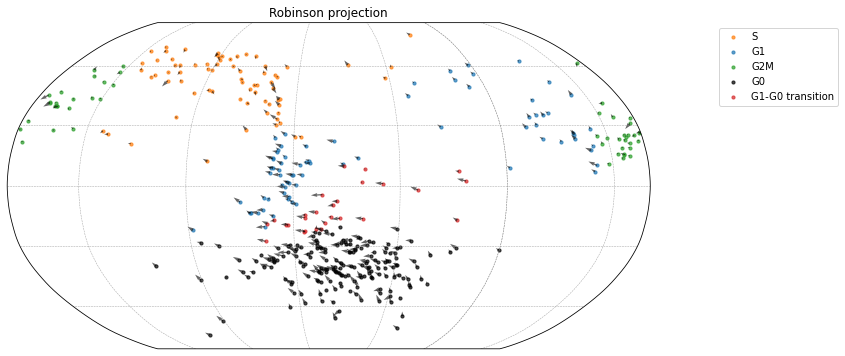

In [ ]:
# If you haven't rotated the sphere yet, you will have to for this projection 
# rotate all the points in the sphere so the top of the cycle pole is north (Lat: 90)
z_df_rotated = obo.rotate_north(z_df)


obo.plot_robinson_projection(
    z_df_rotated, 
    colour_by = 'KNN_phase',
    velocity_df=vel_df, 
    palette=None, 
    ref_df=None,
    central_longitude=80, 
    title="Robinson projection", 
    alpha=0.7,
    scale=3
    
)